# scitex_seizure_metrics — Paper-replica: Andrade 2024 sample-vs-alarm gap

Andrade et al. 2024 ([10.3389/fnins.2024.1417748](https://doi.org/10.3389/fnins.2024.1417748)) showed that 50/56 patients beat chance under sample-based evaluation but **only 6/46 under alarm-based**. The gap is the headline finding — and `scitex_seizure_metrics.papers.andrade2024.metrics(...)` reproduces both sides on the same predictor in one call.

**What this notebook covers**

1. Three synthetic patients with deliberately different signal strengths.
2. Run `andrade2024.metrics` on each.
3. Visualise the sample-vs-alarm scatter — which patients beat chance, and on which axis.

---
**figrecipe drop-in note** — this notebook uses `figrecipe.subplots()` instead of `matplotlib.pyplot.subplots()`. figrecipe returns a `RecordingFigure` + `RecordingAxes` pair that proxies every standard matplotlib method, so every line below is a verbatim copy of the matplotlib version — no API changes — but the figure can now also be saved as a reproducible bundle via `fg.save(fig, 'recipe.zip')`.

**Terminology** (the jargon used below; see the project README for the full glossary):

| Term | Meaning |
| --- | --- |
| **SPH** (`sph_seconds`) | *Seizure-Prediction Horizon* — minimum lead-time between an alarm firing and the seizure onset. Alarms that fire later than SPH before the seizure are not credited. |
| **SOP** (`sop_seconds`) | *Seizure-Occurrence Period* — the window after SPH during which the predicted seizure must actually occur for the alarm to count as a true positive. Defines `[SPH, SPH + SOP]`. |
| **Cadence** (`cadence_seconds`) | How often a fresh "is the warning on?" decision is emitted. |
| **Refractory** (`refractory_seconds`) | Post-alarm silent window that suppresses redundant alarms around a single seizure. |
| **FP/hr** | False-positive alarms per hour, normalised by `fp_denominator`: `'total'` recording time (Cook 2013, Karoly 2017) or `'interictal'`-only time (Mormann tradition). |
| **IoC** | *Improvement over Chance* — signed gap between the model's alarm-based sensitivity and a chance-baseline (Poisson surrogate by default). |
| **TIW** | *Time-In-Warning* — fraction of recording time the warning is active. The natural denominator that pairs with sensitivity in the Proix 2021 operating curve. |
| **AUROC / AUPRC / Brier / MCC / ECE** | Sample-based metrics (per-window classification). See `01_detection_quick_start.ipynb` and the README glossary. |


In [1]:
%matplotlib inline
import warnings

warnings.filterwarnings('ignore', category=UserWarning)

import figrecipe as fg  # drop-in: returns RecordingFigure / RecordingAxes
import matplotlib.pyplot as plt  # kept for plt.tight_layout / plt.show
import numpy as np
import pandas as pd

import scitex_seizure_metrics
from scitex_seizure_metrics.papers import andrade2024

scitex_seizure_metrics.__version__

'0.1.0'

## 1. Three synthetic patients

Each patient has a 24-hour stream at 60-second cadence with three seizures and a pre-ictal ramp. Signal strength varies — `weak`, `medium`, `strong`.

In [2]:
def synth_patient(seed, ramp_height):
    rng = np.random.default_rng(seed)
    duration = 24 * 3600
    times = np.arange(0, duration, 60.0)
    seizures = np.array([4 * 3600, 11 * 3600, 19 * 3600], dtype=float)
    proba = rng.uniform(0, 0.3, size=times.size)
    for sz in seizures:
        ramp_mask = (times >= sz - 3600) & (times < sz - 600)
        proba[ramp_mask] += np.linspace(0.0, ramp_height, ramp_mask.sum())
    proba = np.clip(proba, 0, 1)
    # Sample-based label: 1 inside the [-SPH-SOP, -SPH] window before each seizure
    sph, sop = 300.0, 1800.0
    y_true = np.zeros_like(times, dtype=int)
    for sz in seizures:
        y_true[(times >= sz - sph - sop) & (times < sz - sph)] = 1
    return times, proba, seizures, y_true

patients = {
    'P01_weak':   synth_patient(0, 0.20),
    'P02_medium': synth_patient(1, 0.45),
    'P03_strong': synth_patient(2, 0.80),
}
for k, (t, p, _, y) in patients.items():
    print(f'{k:12s}  prevalence={y.mean():.2%}  mean_proba={p.mean():.3f}')

P01_weak      prevalence=6.25%  mean_proba=0.163
P02_medium    prevalence=6.25%  mean_proba=0.175
P03_strong    prevalence=6.25%  mean_proba=0.194


## 2. Run `andrade2024.metrics` on each patient

In [3]:
rows = []
for pid, (times, proba, seizures, y_true) in patients.items():
    out = andrade2024.metrics(
        y_true=y_true,
        y_proba=proba,
        times_seconds=times,
        seizure_times=seizures,
        sph_seconds=300,
        sop_seconds=1800,
        n_surrogate=200,
        name=pid,
    )
    out['patient'] = pid
    rows.append(out)

df = pd.DataFrame(rows).set_index('patient')
df.round(3)

,paper,name,sample_auroc,sample_pr_auc,sample_sensitivity,sample_specificity,sample_mcc,alarm_sensitivity,alarm_fp_per_hour,alarm_time_in_warning_frac,alarm_ioc,beats_chance_alarm
patient,,,,,,,,,,,,
P01_weak,andrade2024,P01_weak,0.802,0.499,0.000,NaN,0.000,0.0,0.000,0.000,0.000,False
P02_medium,andrade2024,P02_medium,0.918,0.809,0.356,1.000,0.584,1.0,0.000,0.063,0.947,True
P03_strong,andrade2024,P03_strong,0.906,0.849,0.811,0.992,0.829,0.0,0.145,0.063,-0.053,False


## 3. Sample-vs-alarm scatter

x-axis: the sample-based metric (AUROC). y-axis: the alarm-based metric (sensitivity). Each point is a patient. The diagonal is the naïve expectation that a high sample-based score implies a high alarm-based score — Andrade 2024's finding is that the diagonal does **not** hold.

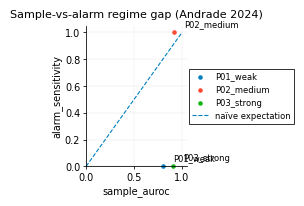

In [4]:
fig, ax = fg.subplots()
x_col = 'sample_auroc' if 'sample_auroc' in df.columns else df.columns[0]
y_col = 'alarm_sensitivity' if 'alarm_sensitivity' in df.columns else df.columns[1]
for pid, row in df.iterrows():
    ax.scatter(row[x_col], row[y_col], label=pid)
    ax.annotate(pid, (row[x_col], row[y_col]),
                xytext=(7, 4), textcoords='offset points')
ax.plot([0, 1], [0, 1], '--', label='naïve expectation')
ax.set_xlabel(x_col)
ax.set_ylabel(y_col)
ax.set_xlim(0, 1.05)
ax.set_ylim(0, 1.05)
ax.set_title('Sample-vs-alarm regime gap (Andrade 2024)')
ax.grid(True, alpha=0.3)
ax.legend()


## 4. Beats-chance bar chart

Side-by-side bars: how many patients beat chance under each regime. This is the canonical Andrade 2024 figure (in their data: 50/56 sample, 6/46 alarm).

In [5]:
sample_col = 'beats_chance_sample' if 'beats_chance_sample' in df.columns else None
alarm_col  = 'beats_chance_alarm'  if 'beats_chance_alarm'  in df.columns else None

if sample_col and alarm_col:
    counts = pd.Series({
        'beats chance (sample)': df[sample_col].sum(),
        'beats chance (alarm)':  df[alarm_col].sum(),
    })
    fig, ax = fg.subplots()
    bars = ax.bar(counts.index, counts.values)
    ax.set_ylabel(f'patients beating chance (of {len(df)})')
    ax.set_title('Regime gap — synthetic 3-patient cohort')
    ax.set_ylim(0, len(df) + 0.5)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 0.05, f'{val}/{len(df)}',
                ha='center')
else:
    print('beats_chance_* columns not present in this build of andrade2024.metrics')
    print('available columns:', list(df.columns))

beats_chance_* columns not present in this build of andrade2024.metrics
available columns: ['paper', 'name', 'sample_auroc', 'sample_pr_auc', 'sample_sensitivity', 'sample_specificity', 'sample_mcc', 'alarm_sensitivity', 'alarm_fp_per_hour', 'alarm_time_in_warning_frac', 'alarm_ioc', 'beats_chance_alarm']


## Where to next

- **`scitex_seizure_metrics.papers.{cook2013, karoly2017, kuhlmann2018, maturana2020, proix2021, stirling2021}`** — same `metrics(...)` signature for each paper's preferred metric set.
- **`03_bridge_sample_to_alarm.ipynb`** — analytic bounds for putting one regime's published number on the other regime's axis without re-running the original method.
- **`scitex_seizure_metrics.surrogates`** — registry of chance-baseline alarm generators (`poisson`, `periodic`, `circadian`, `multidien`, ...) for stricter beats-chance nulls.